## Removing missing vlaues

#### Col

1. `>50%` data missing: rm col
2. importance of col



#### Row

1. listwise deletion(row deletion)/CCA - when small %(<5%) of data is missing
2. if data is MCAR
3. pro: preserves the distribution
4. con: expect no missing val in projection(user has to input all data else `Error`)

In [1]:
import pandas as pd
import numpy as np

import missingno as msno
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day35-complete-case-analysis/data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [3]:
(df.isnull().sum()/len(df))*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

* cols with >5% missing data: gender, major_discipline, company_size, company_type
* so forget them for now apply CCA on other cols with missing vale(<5%)

<Axes: >

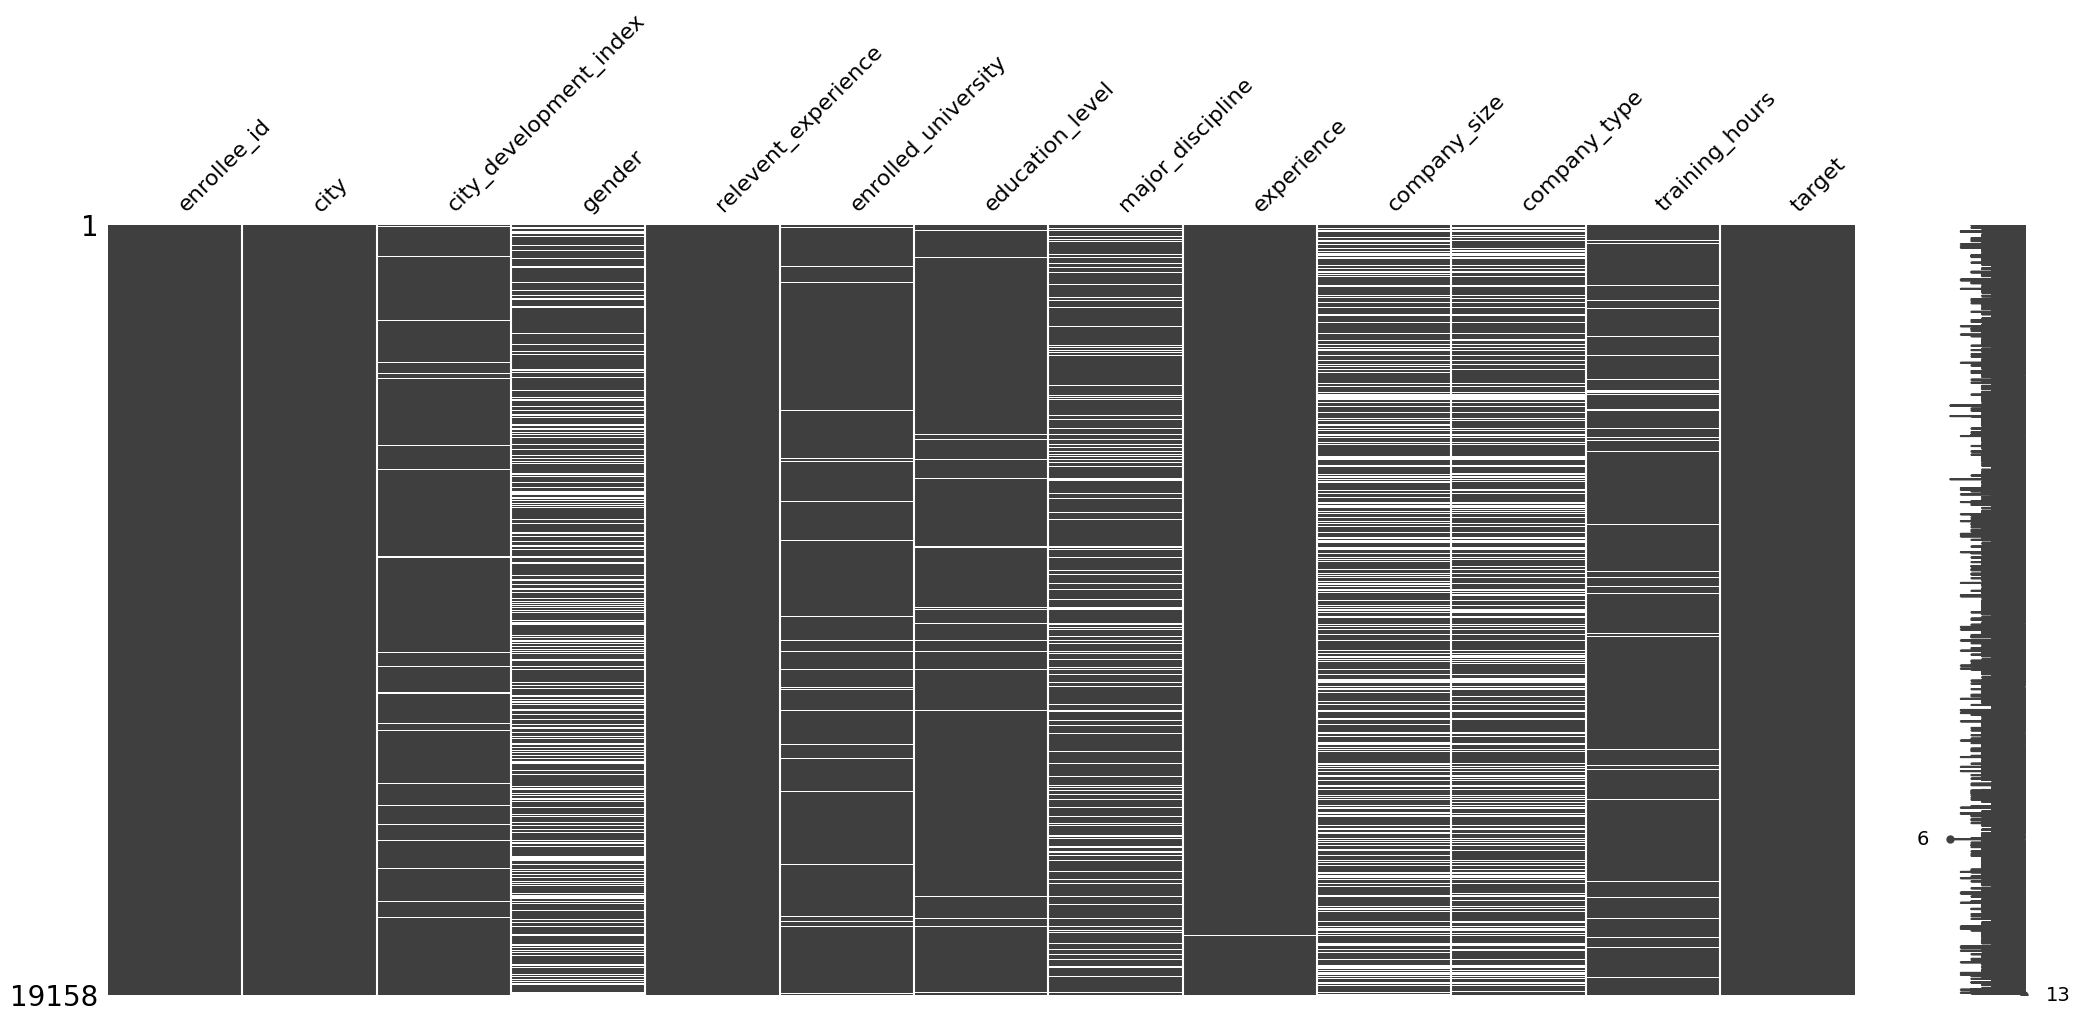

In [4]:
msno.matrix(df)

#### Assumption df is MCAR and matrx also indicates towards that

In [5]:
df = df[['city_development_index','enrolled_university','education_level','training_hours','experience']]
df.head()

,city_development_index,enrolled_university,education_level,training_hours,experience
0,0.920,no_enrollment,Graduate,36.0,20.0
1,0.776,no_enrollment,Graduate,47.0,15.0
2,0.624,Full time course,Graduate,83.0,5.0
3,0.789,NaN,Graduate,52.0,0.0
4,0.767,no_enrollment,Masters,8.0,20.0


In [6]:
df.shape

(19158, 5)

In [7]:
### CCA applied

df_new = df.dropna()
df_new.shape

(17182, 5)

In [8]:
len(df_new)/len(df)

0.8968577095730244

#### Lost 5%+ data(~10%) this isnt acceptable in realworld but for the sake of studying we can proceed

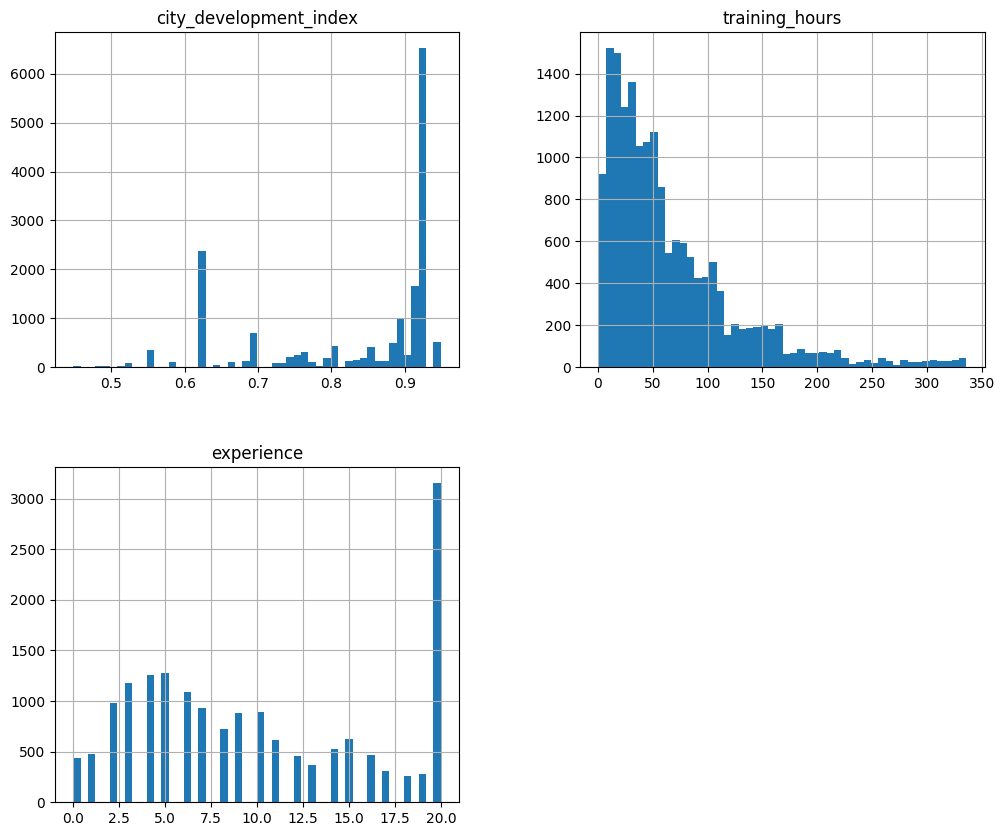

In [9]:
df_new.hist(bins=50, figsize=(12,10))
plt.show()

df_new.hist(bins=50, figsize=(12,10))
plt.show()

<Axes: >

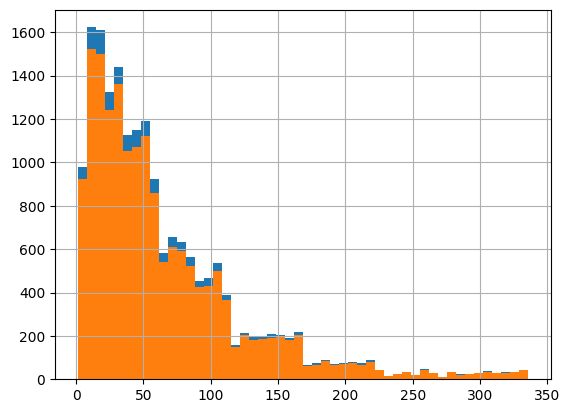

In [10]:
df['training_hours'].hist(bins=50)

df_new['training_hours'].hist(bins=50)

<Axes: ylabel='Density'>

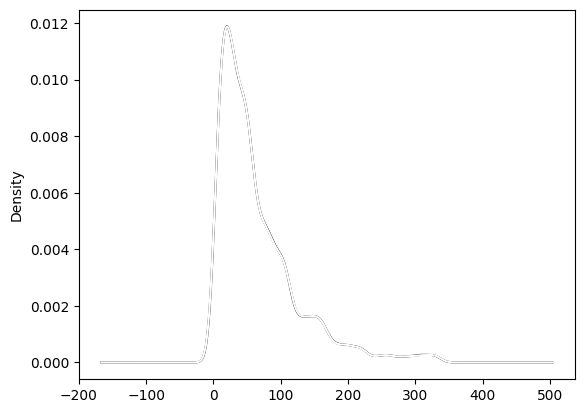

In [11]:
df['training_hours'].plot.density(color='black')

df_new['training_hours'].plot.density(color='white')

<Axes: >

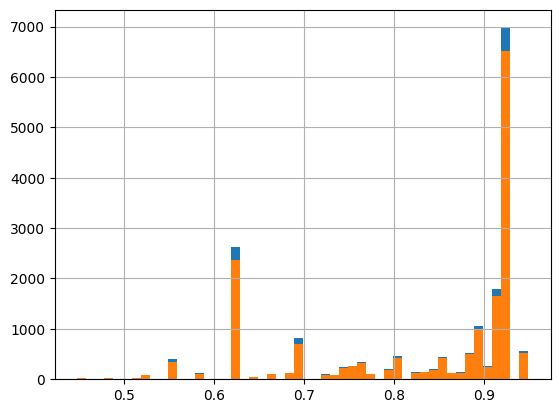

In [12]:
df['city_development_index'].hist(bins=50)

df_new['city_development_index'].hist(bins=50)

#### sine distribution and density plot are very similar there for we can conclude that CCA was a good decision

## Now for categorical columns check before and after PMF(Probability Mass Function) 

In [13]:
temp= pd.concat([df['enrolled_university'].value_counts()/len(df),
    
    df_new['enrolled_university'].value_counts()/len(df)],
               axis=1)

temp.columns=['before','after CCA']
temp

,before,after CCA
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


# Imputation

* Missing Indicator: replaces has deta = 1, nan = 0
* use when 50%+ data is missing in a col, missingness is informative, data is MNAR
* better than droping whole 

In [14]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv',usecols=['Age','Fare', 'Cabin','Survived'])
df.head()

,Survived,Age,Fare,Cabin
0,0,22.0,7.2500,NaN
1,1,38.0,71.2833,C85
2,1,26.0,7.9250,NaN
3,1,35.0,53.1000,C123
4,0,35.0,8.0500,NaN


In [16]:
df.isnull().sum()/len(df)

Survived    0.000000
Age         0.198653
Fare        0.000000
Cabin       0.771044
dtype: float64

#### 77% data is missing in cabin

* result after droping cabin completely: `61%`

### Better method:

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [45]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=67)

In [46]:
T = ColumnTransformer(
    transformers=[
        ('t1',SimpleImputer(),['Age']),
        ('t2',MissingIndicator(),['Cabin'])    
],remainder='passthrough')

In [47]:
X_train_new = T.fit_transform(X_train)
X_test_new = T.fit_transform(X_test)

In [48]:
m = LogisticRegression()

m.fit(X_train_new,Y_train)

pred = m.predict(X_test_new)

accuracy_score(pred,Y_test)

0.6256983240223464

### Accuracy increased

#### cons of this technique: 
* If MCAR
* If very small % of data is missing
* risk of over fitting: if applied on many cols without droping them: feature expansion

## Simple Imputation

### SimpleImputation-mean

#### when to use:

* MCAR
* Data is roughly normally distributed
* % of missing value in small(~5%)

#### Dont use when:

* if variance is reduced alot after applying mean imputation
* if out liers are intrduced

use `median` instead

### SimpleImputation-most_frequent(mode)

#### When to use?:

* MCAR
* Less no of data points missing
* One dominant category


### SimpleImputer - Constant

#### When to use?:

* MNAR
* Missing has a meaning
* You wanna preserve the distribution

Cateogrical col:

```` python
city: MUM,DEL,KOL,CHEN,nan --- We can replace this nan with somethign that indicates that there is a missing value ['no' or 'null', etc]
````

Numerical col:

````python
Age: 13,53,23,54,23,54, nan --- We can replace all nan with a value that doesnt mix in with other numbers [-1,999, etc]
````